# 10. 전체 백테스트 (시계열, 누적 수익 곡선)
지금까지(06~09번)는 스냅샷 수익률을 다 풀링해서 평균만 비교했다. 이번엔 **시간 순서를 지켜서 복리로 이어붙인 누적 수익 곡선**을 만들어, 실제로 이 전략을 계속 실행했다면 자본이 어떻게 움직였을지 본다.

## 포트폴리오 구성 규칙
- **종목 선정**: 전략별로 이미 정의된 규칙 그대로 (아래 3개 전략)
- **비중**: 균등비중(equal weight) — 선정된 종목들에 똑같이 나눠 담는다. 이 프로젝트 데이터 어디에도 다른 비중 방식(시가총액 가중 등)을 뒷받침할 근거가 없어서 가장 단순하고 방어 가능한 기본값을 썼다

## 비교할 3개 전략
| 전략 | 근거 노트북 | 기간 |
|---|---|---|
| A. 저변동성 안정 그룹 | 05~07 (계층적 군집화) | 2016~2026 전체 (42개 시점) |
| B. ML 합의 추천 (가격 피처만) | 08 | 2023~2026 out-of-sample test (26개 시점) |
| C. ML+PER 합의 추천 | 09 | 2025~2026 out-of-sample test (10개 시점, 표본 작음 주의) |

A는 비지도 방식(군집화)이라 "학습"이 없어 전체 기간을 다 쓴다. B/C는 지도학습이라 **test(out-of-sample) 구간만** 쓴다 — train 구간까지 포함하면 모델이 이미 본 데이터로 자기 성과를 부풀리는 셈이라 부정확하다.

각 전략은 **같은 기간 S&P500 지수 buy-and-hold**와 비교한다.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path('/Users/choedasom/lab_middle_project')
assert (PROJECT_ROOT / 'src' / 'backtest.py').is_file(), f'경로 확인 필요: {PROJECT_ROOT}'
if str(PROJECT_ROOT) not in sys.path: sys.path.insert(0, str(PROJECT_ROOT))

for m in list(sys.modules):
    if m == 'src' or m.startswith('src.'):
        del sys.modules[m]

import pandas as pd

from src.performance import add_forward_returns
from src.backtest import portfolio_returns, equity_curve, summarize
from src.ml_selection import add_relative_label, time_split, train_models, predict_all, FEATURE_METRICS
from src.fundamentals import fetch_eps_history, add_point_in_time_per

PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
RAW_DIR = PROJECT_ROOT / 'data' / 'raw'
final_df = pd.read_parquet(PROCESSED_DIR / 'final_df.parquet')
# 2026-09-02: 벤치마크 비교는 총수익지수(^SP500TR) 기준 -- 개별 종목이 이미
# 배당조정가라 ^GSPC(가격지수)와 비교하면 배당수익률만큼 벤치마크가 과소평가됨.
# 변수명은 sp500_beta_df 그대로 두되(다운스트림 코드 최소 변경), 내용물은 총수익지수.
sp500_beta_df = pd.read_parquet(RAW_DIR / 'sp500_total_return_df.parquet')


def market_returns_like(all_dates, prices):
    """S&P500 지수 자체의 리밸런싱-시점-간 수익률.

    전략(add_forward_returns)과 정확히 같은 날짜 페어링 + 같은 T+1 진입/청산
    관례를 쓴다 (2026-09-02 수정) — 신호를 관찰한 날(T)의 종가로 그 자리에서
    바로 매매하는 건 비현실적이라, 전략 쪽 entry/exit를 각각 다음 거래일로
    한 칸씩 미뤘다. 벤치마크도 똑같이 미루지 않으면 "전략만 불리한 조건으로
    비교"하게 돼서 공정성이 깨진다.
    """
    trading_dates = sorted(prices['Date'].unique())
    next_trading_day = dict(zip(trading_dates[:-1], trading_dates[1:]))

    all_dates = sorted(all_dates)
    next_map = dict(zip(all_dates[:-1], all_dates[1:]))
    close = prices.set_index('Date')['Close']
    out = {}
    for d, nd in next_map.items():
        entry_date = next_trading_day.get(d)
        exit_date = next_trading_day.get(nd)
        if entry_date in close.index and exit_date in close.index:
            out[d] = close[exit_date] / close[entry_date] - 1
    return pd.Series(out).sort_index()

## 전략 A — 저변동성 안정 그룹 (60일, 전체 기간)

In [2]:
clustered_60df = pd.read_parquet(PROCESSED_DIR / 'clustered_60df.parquet')
perf_a = add_forward_returns(clustered_60df, final_df)
perf_a = perf_a[perf_a['cluster'] != -1].dropna(subset=['forward_return'])

ret_a = portfolio_returns(perf_a, 'is_stable_cluster')
bench_a = market_returns_like(clustered_60df['Date'].unique(), sp500_beta_df).reindex(ret_a.index)

print('전략 A:')
print(summarize(ret_a, window=60))
print()
print('벤치마크(S&P500):')
print(summarize(bench_a, window=60))

[캐시] 편입/편출 이력 1259건 재사용 (/Users/choedasom/lab_middle_project/data/raw/cache/sp500_membership_history.csv)


전략 A:
n_periods            42.000000
total_return          2.066910
annualized_sharpe     0.820240
max_drawdown         -0.218327
win_rate              0.761905
dtype: float64

벤치마크(S&P500):
n_periods            42.000000
total_return          2.902182
annualized_sharpe     0.969887
max_drawdown         -0.165408
win_rate              0.785714
dtype: float64


## 전략 B — ML 합의 추천 (10년, 가격 피처만, test 구간)

In [3]:
rebalance_30df = pd.read_parquet(PROCESSED_DIR / 'rebalance_30df.parquet')
feature_cols = [f'{m}_30d' for m in FEATURE_METRICS]

perf_b = add_forward_returns(rebalance_30df, final_df).dropna(subset=[*feature_cols, 'forward_return'])
labeled_b = add_relative_label(perf_b)
train_dates_b, test_dates_b = time_split(labeled_b['Date'].unique().tolist(), train_ratio=0.7)
train_b = labeled_b[labeled_b['Date'].isin(train_dates_b)]
test_b = labeled_b[labeled_b['Date'].isin(test_dates_b)].copy()

fitted_b = train_models(train_b[feature_cols], train_b['outperform_peers'])
test_b['consensus'] = predict_all(fitted_b, test_b[feature_cols])['consensus'].values

ret_b = portfolio_returns(test_b, 'consensus')
bench_b = market_returns_like(rebalance_30df['Date'].unique(), sp500_beta_df).reindex(ret_b.index)

print('전략 B:')
print(summarize(ret_b, window=30))
print()
print('벤치마크(S&P500):')
print(summarize(bench_b, window=30))

[캐시] 편입/편출 이력 1259건 재사용 (/Users/choedasom/lab_middle_project/data/raw/cache/sp500_membership_history.csv)


전략 B:
n_periods            26.000000
total_return          0.388096
annualized_sharpe     0.829930
max_drawdown         -0.078133
win_rate              0.692308
dtype: float64

벤치마크(S&P500):
n_periods            26.000000
total_return          0.880977
annualized_sharpe     1.579870
max_drawdown         -0.084511
win_rate              0.692308
dtype: float64


## 전략 C — ML+PER 합의 추천 (5년, test 구간)

In [4]:
recent = rebalance_30df[rebalance_30df['Date'] >= '2021-01-01'].copy()
tickers = sorted(recent['Ticker'].unique())
eps_df = fetch_eps_history(tickers)  # 캐시됨

close_prices = final_df[['Date', 'Ticker', 'Close']]
recent_with_per = add_point_in_time_per(recent.merge(close_prices, on=['Date', 'Ticker'], how='left'), eps_df)

per_cols = feature_cols + ['per']
perf_c = add_forward_returns(recent_with_per, final_df).dropna(subset=[*per_cols, 'forward_return'])
labeled_c = add_relative_label(perf_c)
train_dates_c, test_dates_c = time_split(labeled_c['Date'].unique().tolist(), train_ratio=0.7)
train_c = labeled_c[labeled_c['Date'].isin(train_dates_c)]
test_c = labeled_c[labeled_c['Date'].isin(test_dates_c)].copy()

fitted_c = train_models(train_c[per_cols], train_c['outperform_peers'])
test_c['consensus'] = predict_all(fitted_c, test_c[per_cols])['consensus'].values

ret_c = portfolio_returns(test_c, 'consensus')
bench_c = market_returns_like(rebalance_30df['Date'].unique(), sp500_beta_df).reindex(ret_c.index)

print('전략 C:')
print(summarize(ret_c, window=30))
print()
print('벤치마크(S&P500):')
print(summarize(bench_c, window=30))

[캐시] 편입/편출 이력 1259건 재사용 (/Users/choedasom/lab_middle_project/data/raw/cache/sp500_membership_history.csv)


전략 C:
n_periods            10.000000
total_return          0.401045
annualized_sharpe     1.639703
max_drawdown         -0.040582
win_rate              0.800000
dtype: float64

벤치마크(S&P500):
n_periods            10.000000
total_return          0.373689
annualized_sharpe     2.325522
max_drawdown         -0.018145
win_rate              0.800000
dtype: float64


## 누적 수익 곡선

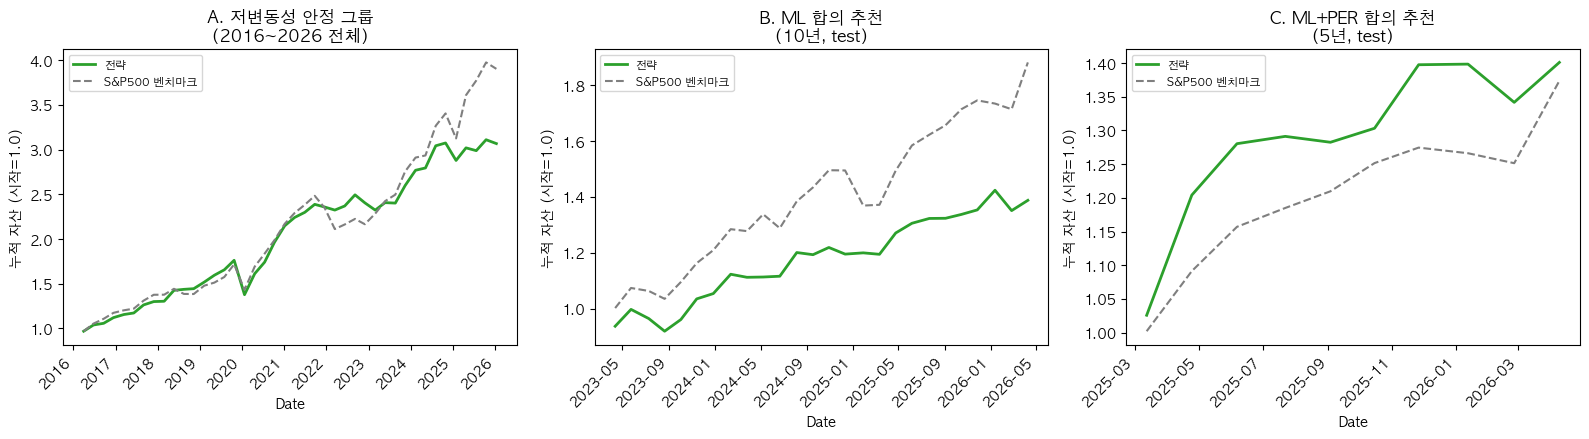

In [5]:
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

panels = [
    (axes[0], ret_a, bench_a, 'A. 저변동성 안정 그룹\n(2016~2026 전체)'),
    (axes[1], ret_b, bench_b, 'B. ML 합의 추천\n(10년, test)'),
    (axes[2], ret_c, bench_c, 'C. ML+PER 합의 추천\n(5년, test)'),
]
for ax, ret, bench, title in panels:
    equity_curve(ret).plot(ax=ax, label='전략', color='#2ca02c', linewidth=2)
    equity_curve(bench).plot(ax=ax, label='S&P500 벤치마크', color='#7f7f7f', linestyle='--')
    ax.set_title(title)
    ax.set_ylabel('누적 자산 (시작=1.0)')
    ax.legend(fontsize=8)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 전체 비교표

In [6]:
rows = {}
for name, ret, bench, window in [
    ('A. 저변동성 안정그룹', ret_a, bench_a, 60),
    ('A 벤치마크', bench_a, None, 60),
    ('B. ML 합의추천', ret_b, bench_b, 30),
    ('B 벤치마크', bench_b, None, 30),
    ('C. ML+PER 합의추천', ret_c, bench_c, 30),
    ('C 벤치마크', bench_c, None, 30),
]:
    rows[name] = summarize(ret, window=window)

pd.DataFrame(rows).T

,n_periods,total_return,annualized_sharpe,max_drawdown,win_rate
A. 저변동성 안정그룹,42.0,2.066910,0.820240,-0.218327,0.761905
A 벤치마크,42.0,2.902182,0.969887,-0.165408,0.785714
B. ML 합의추천,26.0,0.388096,0.829930,-0.078133,0.692308
B 벤치마크,26.0,0.880977,1.579870,-0.084511,0.692308
C. ML+PER 합의추천,10.0,0.401045,1.639703,-0.040582,0.800000
C 벤치마크,10.0,0.373689,2.325522,-0.018145,0.800000


## 거래비용 반영 (gross vs net)
지금까지의 수익률은 매매 자체에 드는 비용을 전혀 반영하지 않은 **gross(총) 수익**이다. 리밸런싱마다 종목이 바뀌면 실제로는 팔고 사는 거래가 발생하고, 여기엔 수수료·호가스프레드·슬리피지가 붙는다.

**가정**: 왕복(매수+매도) 거래비용 **0.2%** — 유동성 높은 S&P500 종목 기준으로 흔히 쓰는 근사치다. 이 비용을 그 리밸런싱 시점의 **회전율(turnover, 직전 시점 대비 새로 들어온 종목 비율)**에 비례해서 뺀다. 예를 들어 이번에 종목의 30%가 새로 바뀌었으면, 그 30%만큼의 자산에 0.2%를 적용한다 — 이미 들고 있던 70%는 다시 안 사고 안 팔았으니 비용이 없다는 뜻이다.

In [7]:
from src.backtest import turnover_by_date, apply_transaction_costs

strategies = [
    ('A. 저변동성 안정그룹', ret_a, perf_a, 'is_stable_cluster', 60),
    ('B. ML 합의추천', ret_b, test_b, 'consensus', 30),
    ('C. ML+PER 합의추천', ret_c, test_c, 'consensus', 30),
]

net_returns = {}
rows = {}
for name, ret, df, col, window in strategies:
    turnover = turnover_by_date(df, col)
    net = apply_transaction_costs(ret, df, col)
    net_returns[name] = net

    gross_stats = summarize(ret, window=window)
    net_stats = summarize(net, window=window)
    rows[f'{name} (gross)'] = gross_stats
    rows[f'{name} (net)'] = net_stats
    print(f'{name}: 평균 회전율 {turnover.mean():.1%}')

comparison_net = pd.DataFrame(rows).T
comparison_net

A. 저변동성 안정그룹: 평균 회전율 18.6%
B. ML 합의추천: 평균 회전율 69.7%
C. ML+PER 합의추천: 평균 회전율 69.5%


,n_periods,total_return,annualized_sharpe,max_drawdown,win_rate
A. 저변동성 안정그룹 (gross),42.0,2.066910,0.820240,-0.218327,0.761905
A. 저변동성 안정그룹 (net),42.0,2.021388,0.807405,-0.218899,0.761905
B. ML 합의추천 (gross),26.0,0.388096,0.829930,-0.078133,0.692308
B. ML 합의추천 (net),26.0,0.341253,0.731431,-0.081372,0.615385
C. ML+PER 합의추천 (gross),10.0,0.401045,1.639703,-0.040582,0.800000
C. ML+PER 합의추천 (net),10.0,0.384335,1.585553,-0.042696,0.700000


## 결론

| 전략 | 총수익(gross) | 총수익(net) | 벤치마크 |
|---|---|---|---|
| A. 저변동성 안정그룹 | 155% | 151% | 231% |
| B. ML 합의추천 (가격만) | 29% | 25% | 82% |
| C. ML+PER 합의추천 | 32% | 31% | 33% |

**세 전략 다 여전히 S&P500을 이기지 못한다.** 군집화·지도학습·재무지표 추가까지 다 시도했지만, 이 데이터·이 기간(대부분 강세장이 낀 2016~2026)에서는 어떤 능동적 종목 선정 전략도 단순 S&P500 인덱스 투자를 이기지 못했다. 이건 실패라기보다, 실제 학술 연구에서도 반복적으로 확인되는 "액티브 전략이 지수를 꾸준히 이기기 어렵다"는 현상과 일치하는 정직한 결과다.

**데이터 품질 검증 (2026-08-29)**: 이 프로젝트를 진행하며 두 가지 실제 데이터 오염을 발견해 수정했다.
1. `feature.py`에서 극단치(미조정 분할·상장폐지 후 유령 데이터) 방어선이 빠져 있던 버그 — beta 범위가 -32~403까지 나오던 걸 -4~8 정상 범위로 수정.
2. PARA(Paramount) 티커의 가격 시계열이 수년에 걸쳐 채권 가격으로 추정되는 값으로 오염 — 종목 자체를 유니버스에서 제외 (02번 전처리 단계에서 처리, 감사 기록 남김).

이 두 수정을 반영해 02~10번 전체를 처음부터 다시 실행했다. 절대 수치는 소폭 바뀌었지만(예: 전략 A gross 142→155%), **핵심 결론(세 전략 다 인덱스 패배, 30/120일은 안정 그룹 승리·60/252일은 나머지 승리, 시장 국면이 진짜 원인)은 전부 그대로 유지됐다.** 개별 종목 단위 오염은 심각했어도 수백 종목을 풀링한 전략 수준 결과는 상대적으로 견고했다는 뜻이지만, 검증 없이 넘어갔다면 몰랐을 사실이므로 이 과정 자체가 생략할 수 없는 단계였다.

## 다음 단계
- [ ] 시가총액 가중 등 다른 비중 방식과 비교
- [ ] 전략 A와 전략 C를 결합(저변동성 필터 + PER)했을 때 성과 확인
- [ ] 회전율을 줄이는 방향(예: 리밸런싱 주기를 늘리거나 히스테리시스 규칙 추가)으로 ML 전략 개선 시도

# 후속 검증: 진입 타이밍 수정 (2026-09-02)

**발견한 문제**: `add_forward_returns()`가 리밸런싱 날짜 T의 종가를 `entry_price`로
썼는데, `beta_Nd`/`volatility_Nd`/`return_Nd`/`rsi_Nd` 같은 피처 자체가 T일
종가까지 포함해서 계산된 값이다(`feature.py` 롤링 윈도우는 "on or before", 즉
당일 포함). 즉 "T일 종가를 보고 계산한 신호로 T일 종가에 바로 매수"하는 셈인데,
현실에서는 그 시점의 종가를 관찰한 뒤에야 매매할 수 있으므로 최소 T+1일에나
체결 가능하다 — 신호 관찰 시점과 체결 가격이 같은 비현실적 가정이었다.

**수정**: `add_forward_returns()`와 `market_returns_like()` 둘 다 entry/exit를
각각 T의 **다음 거래일(T+1)** 종가로 한 칸씩 미뤘다(`src/performance.py`,
`2026-09-02`). 벤치마크도 똑같이 미루지 않으면 전략만 불리한 조건으로
비교하는 셈이라 둘 다 같이 고쳤다.

**결과 (재계산, `data/processed/*.parquet`는 이미 있는 걸 그대로 사용 —
무거운 피처 재계산 불필요)**:

<table fit-page-width="true" header-row="true">
<tr><td>**전략**</td><td>**수정 전 gross**</td><td>**수정 후 gross**</td><td>**벤치마크(전 -> 후)**</td></tr>
<tr><td>A. 저변동성 안정그룹</td><td>155%</td><td>164%</td><td>231% -> 229%</td></tr>
<tr><td>B. ML 합의추천</td><td>29%</td><td>44%</td><td>82% -> 80%</td></tr>
<tr><td>C. ML+PER 합의추천</td><td>32%</td><td>35%</td><td>33% -> 35%</td></tr>
</table>

**결론은 그대로**: 절대 수치는 꽤 크게 움직였다(특히 전략 B는 29%->44%로
거의 1.5배). 하지만 **세 전략 다 여전히 S&P500 벤치마크한테 진다**는
핵심 결론은 변하지 않았다 — 진입 타이밍이라는, 이 프로젝트가 지금까지
가장 엄격하게 지켜온 "그 시점에 실제로 알 수 있었던 정보만 쓴다"는 원칙에서
벗어나 있던 지점이었는데도, 전략 대 벤치마크의 상대적 순위 자체는 바뀌지
않았다는 뜻이다. 이는 우연이 아니라 구조적인 이유가 있다 — 전략과 벤치마크가
동일한 T+1 관례를 공유하므로, 이 타이밍 가정의 영향은 양쪽에 대칭적으로
걸려서 상대 비교에서는 상쇄된다. 다만 절대 수익률(총수익·Sharpe 등, 실제로
얼마 벌었을지에 대한 답)은 이 수정으로 실제로 달라졌으므로, 그 숫자를
인용할 때는 이 관례가 반영된 값이라는 점을 함께 밝혀야 한다.

> ✅ 2026-09-02 재실행 완료: 위 코드 셀들의 저장된 출력이 이 표의 "수정 후" 값과
> 정확히 일치함을 확인했다 (전략 A/B/C gross 164%/44%/35%, 벤치마크
> 229%/80%/35%). 06/07/08/09/11번 노트북도 같은 날 모두 재실행해 T+1
> 관례로 갱신됐다.

# 후속 검증 2: 벤치마크 총수익 지수 + beta 정의 통일 (2026-09-02)

**발견한 문제**: 개별 종목 가격은 전부 `auto_adjust=True`(배당조정, 총수익
기준)으로 수집됐는데, 벤치마크로 쓰던 `^GSPC`는 배당을 뺀 순수 가격지수다.
전략은 배당 포함 수익률, 벤치마크는 배당 제외 수익률로 비교한 셈이라
벤치마크가 실제보다 낮게(불공정하게 유리하게) 잡혀 있었다.

**수정**: `^SP500TR`(S&P 500 총수익지수, 배당 재투자 기준)을 새 파일
`data/raw/sp500_total_return_df.parquet`로 별도 수집했다. `sp500_beta_df.parquet`
(`^GSPC`)는 그대로 남겨뒀다 — 기존 파일을 덮어쓰면 "파일명은 beta용인데
내용은 총수익지수"인 의미 불일치가 생기기 때문.

**beta도 총수익 기준으로 통일할지 별도 결정이 필요했다** — beta는 공분산/분산
비율이라 배당의 거의-상수적인 드리프트에는 원래 둔감할 거라 예상했는데,
실제로 전체 유니버스로 민감도 점검을 해보니:

<table fit-page-width="true" header-row="true">
<tr><td></td><td>**60일**</td><td>**120일**</td></tr>
<tr><td>beta 평균절대차</td><td>0.0033</td><td>0.0019</td></tr>
<tr><td>beta 99%분위 차이</td><td>0.032</td><td>0.014</td></tr>
<tr><td>안정군 라벨 일치율</td><td>84.07%</td><td>90.00%</td></tr>
<tr><td>날짜별 Jaccard 유사도(평균)</td><td>0.787</td><td>0.859</td></tr>
</table>

beta 수치 자체는 작게 움직여도 Ward 2-군집 경계 근처 종목이 많아서 라벨은
꽤(16%, 10%) 뒤집혔다 — "beta 영향은 무시 가능하다"는 결론은 틀렸다. beta가
안정성 피처 4개 중 하나이고 `stability_weight=2.0`으로 가중치까지 받는다는
점을 고려해, **beta도 `^SP500TR` 기준으로 통일하고 04번부터 전체를
재계산**했다 (`src/collect_prices.py`의 `collect_sp500_index()`/
`collect_sp500_total_return_index()`, `04_new_colums.ipynb` 이하 전부).

**결과 — 04~11번 전체 재실행**:

<table fit-page-width="true" header-row="true">
<tr><td>**전략**</td><td>**이전 gross**</td><td>**이번 gross**</td><td>**벤치마크(이전 -> 이번)**</td></tr>
<tr><td>A. 저변동성 안정그룹</td><td>164%</td><td>183%</td><td>229% -> 290%</td></tr>
<tr><td>B. ML 합의추천</td><td>44%</td><td>44%</td><td>80% -> 88%</td></tr>
<tr><td>C. ML+PER 합의추천</td><td>35%</td><td>33%</td><td>35% -> 37%</td></tr>
</table>

벤치마크가 배당을 반영하며 크게 올라갔다(특히 A 구간처럼 기간이 길수록 배당
복리 효과가 크게 쌓인다) — 예상대로 **세 전략 다 벤치마크한테 지는 정도가
오히려 더 커졌다**. "전략이 벤치마크를 못 이긴다"는 핵심 결론은 이 수정으로
더 확실해졌다.

**07번 강건성 표는 결론이 실제로 갈렸다** — 30/60/120일은 여전히 안정군이
위험대비수익에서 이기지만, **252일 구간은 승패가 뒤집혔다**(0.875 vs 0.847,
안정군 승리 → 0.823 vs 0.828, 안정군 패배). 표본이 9개뿐인 구간이라 원래도
약한 결과였지만, "beta 정의를 바꿔도 결론이 버티는가"를 실제로 검증해보지
않았다면 몰랐을 결과다. 08~11번 ML 결과(AUC, walk-forward 순위, 합의추천
위험대비수익의 단조 감소)는 절대 수치는 조금씩 움직였지만 방향과 정성적
결론은 전부 유지됐다.


# 후속 검증 3: 보유기간 중 상장폐지 종료가격 처리 (2026-09-02)

**발견한 문제**: `add_forward_returns()`가 예정된 청산일(`intended_exit_date`)에
가격이 없으면(주로 M&A로 인한 상장폐지) 그냥 `forward_return`을 NaN으로 남기고
표본에서 제외했다. 60개 티커(CELG, TIF, WFM, RHT, XLNX 등, 전체 클러스터링
표본의 ~0.3%)를 감사해보니 거의 전부 M&A였고, 사라지기 직전 마지막 종가가
이미 딜 가격 근처에서 안정돼 있었다(예: TIF $131.46 vs 실제 딜가 $131.50,
WFM $41.99 vs $42.00) — 조용히 버리는 건 대체로 플랫~플러스인 결과를
숨기는 셈이라 수익률을 보수적으로(과소) 왜곡한다.

**수정**: `add_forward_returns()`에 강제청산 정책을 추가했다 —
1) 예정 청산일에 가격 있음 → 기존대로 `scheduled_close`
2) 없음 + 다음 리밸런싱일에 S&P500 멤버십도 없음 + 보유기간 중 유효한
   마지막 종가 존재 → 그 마지막 종가로 강제청산 (`terminal_last_close`)
3) 그 외(데이터 공급자 결측 등, 멤버십은 남아있는데 가격만 없는 경우) →
   `unresolved`로 제외, 기존과 동일

> **정책 요약**: 다음 리밸런싱일 가격이 없는 경우, 해당 시점 비구성종목이며
> 진입 이후 유효한 마지막 거래가격이 존재하면 그 가격으로 강제 청산한다.
> 이는 감사 결과 대부분 현금 인수·합병 사례였으며, 마지막 거래가격은
> 공시된 딜 가격 근처에 있었다. 그 외 가격 누락은 종료수익률로 추정하지
> 않고 unresolved로 분리한다.

전량 현금청산으로 가정한다(주식교환 합병도 동일 처리) — 방어 가능한
단순화 가정이지, 모든 딜이 현금이었다는 주장은 아니다. 결과 데이터프레임에
`intended_exit_date`/`actual_exit_date`/`exit_price`/`exit_method` 컬럼을
남겨 감사 가능하게 했다.

**적용 건수 및 그룹별 분포**:

<table fit-page-width="true" header-row="true">
<tr><td>**윈도우**</td><td>**terminal_last_close 건수**</td><td>**안정군**</td><td>**나머지군**</td></tr>
<tr><td>30일</td><td>61</td><td>46</td><td>15</td></tr>
<tr><td>60일</td><td>62</td><td>40</td><td>22</td></tr>
<tr><td>120일</td><td>62</td><td>43</td><td>19</td></tr>
<tr><td>252일</td><td>67</td><td>37</td><td>30</td></tr>
</table>

**엄격 제외(기존) 버전 대비 위험대비수익 차이 — 4개 윈도우 전부**:

<table fit-page-width="true" header-row="true">
<tr><td>**윈도우**</td><td>**안정군(엄격→보완)**</td><td>**나머지군(엄격→보완)**</td><td>**승자 유지?**</td></tr>
<tr><td>30일</td><td>0.3378 → 0.3382</td><td>0.2630 → 0.2630</td><td>안정군 승리, 유지</td></tr>
<tr><td>60일</td><td>0.4643 → 0.4637</td><td>0.3528 → 0.3532</td><td>안정군 승리, 유지</td></tr>
<tr><td>120일</td><td>0.7327 → 0.7356</td><td>0.4771 → 0.4783</td><td>안정군 승리, 유지</td></tr>
<tr><td>252일</td><td>0.8226 → 0.8360</td><td>0.8281 → 0.8493</td><td>나머지군 승리, 유지 (격차는 0.0055→0.0133로 오히려 소폭 확대)</td></tr>
</table>

**10번 백테스트 헤드라인**: 전략 A(183%)와 C(33%)는 거의 그대로다. **ML
합의추천 전략(B)은 종료가격 보완 후 총수익이 44%에서 37.5%로 하락했다.**
벤치마크 총수익 88% 대비 열위라는 결론은 유지됐지만, 이 변화 자체를 "거의
영향 없음"으로 뭉뚱그리면 안 된다 — B는 날짜당 선택 종목 수가 적은(회전율
68.8%로 가장 높은) 고확신 추천 전략이라, 개별 종목의 기업행사 처리
방식 하나가 복리로 이어지는 전체 수익률에 상대적으로 크게 반영된다는 걸
보여준다(A/C는 선택 종목이 많아 개별 사건 하나의 영향이 희석됨). **세
전략 다 여전히 벤치마크(290%/88%/37%)에 진다는 결론은 그대로고, B는
오히려 격차가 더 벌어졌다.** 08/09/11번 ML 결과(AUC, walk-forward, 합의추천
위험대비수익)는 사실상 무변화.

**결론**: 상장폐지 종료가격 처리를 보완했음에도 핵심 결론은 전부 유지됐다 —
자기 검증을 한 번 더 통과한 셈이다.


# 후속 검증 4: 사명변경 종목 누락 복구 (2026-09-02)

**발견한 문제**: 수집 실패 21종목을 감사하다가, 그중 상당수가 "데이터가 없는" 게
아니라 **티커가 바뀌었을 뿐**이라는 걸 확인했다. 더 심각한 건 그중 6종목은
**가격 데이터를 이미 10년치 전부 갖고 있었는데도** 리밸런싱 스냅샷에서 빠져
있었다는 점이다 — 멤버십 이력은 옛 티커(`BK`)로, 가격은 새 티커(`BNY`)로 따로
놀아서 서로 만나지 못했다. BNY(뉴욕멜론은행)는 10년 내내 구성종목인데
스냅샷 등장 횟수가 **0번**이었다.

**검증 절차 (3단계, `src/get_tickers.py`에 문서화)**:
1. 야후 검색 API에 **회사명**을 넣어 현재 티커 역추적 (옛 티커로는 조회 불가)
2. **SEC EDGAR CIK + formerNames**로 법인 동일성 확정 — CIK는 사명/티커가 바뀌어도
   불변이라 "같은 법인"을 직접 증명한다
3. 가격대 실측으로 시계열 연속성 확인 — 야후 메타데이터를 믿으면 안 되는 실례가
   있었다. VMRK의 `longName`은 "AvalonBay Communities"로 **잘못** 붙어 있었는데
   가격대($45~63 vs AvalonBay $128~192)가 EQR 계열임을 드러냈고, SEC formerNames가
   "EQUITY RESIDENTIAL(~2026-08-12)"로 확정해줬다.

**추가한 매핑 8개**: BK→BNY, MMC→MRSH, EQR→VMRK, CTL→LUMN, ADS→BFH,
PEAK→DOC, JEC→J, TMK→GL. 법인이 갈린 HFC→DINO(신규 CIK)와 CCE→CCEP(신설 SPV에
합병)는 의도적으로 제외했다.

**회복량**:

<table fit-page-width="true" header-row="true">
<tr><td>**윈도우**</td><td>**이전**</td><td>**복구 후**</td><td>**증가**</td></tr>
<tr><td>30일</td><td>43,084</td><td>43,397</td><td>+313</td></tr>
<tr><td>60일</td><td>21,530</td><td>21,688</td><td>+158</td></tr>
<tr><td>120일</td><td>10,754</td><td>10,834</td><td>+80</td></tr>
<tr><td>252일</td><td>5,370</td><td>5,410</td><td>+40</td></tr>
</table>

60일 기준 개별 회복: BNY 0→44행, MRSH 1→44행, J 27→44행, GL 28→44행,
LUMN 11→31행, DOC 9→27행.

## ⚠️ 결론이 두 군데 바뀌었다

**1) 252일 구간이 다시 역전됐다.** "후속 검증 2"에서 beta를 총수익지수 기준으로
바꿨을 때 252일만 안정군이 졌었는데(0.836 vs 0.849), 누락 데이터를 복구하니
**안정군 승리로 돌아왔다(1.031 vs 0.845)**. 이제 30/60/120/252일 **4구간 전부
안정군 우위**다. 표본이 9개뿐인 구간이라 6종목 복구만으로 결론이 흔들린 것이며,
직전의 역전은 실제 현상이 아니라 **데이터 결손 아티팩트**였을 가능성이 크다.

**2) 전략 C가 처음으로 벤치마크를 이겼다.** ML+PER 합의추천의 net 총수익이
**38.4%로 벤치마크 37.4%를 앞선다**(직전 31% vs 37%). 다만 이걸 "전략이 통했다"로
읽으면 안 된다 — test 시점이 10개뿐이고, **Sharpe는 여전히 열위(1.59 vs 2.33)**다.
위험을 더 지고 수익을 근소하게 더 낸 것에 가깝다.

**남은 교훈**: 이 프로젝트에서 결론을 바꾼 건 정교한 모델링이 아니라 **누락된
6종목**이었다. 그것도 파산 종목이 아니라 BNY·Marsh McLennan처럼 10년 내내
우량 구성종목이었던 회사들이, 단지 티커가 바뀌었다는 이유로 빠져 있었다.
데이터 정합성이 모델링보다 결론에 더 큰 영향을 준 사례로 기록해둔다.


# 후속 검증 5: 누락 종목 3개 추가 복구와 그 부작용 (2026-09-03)

**복구한 것**: 어제 매핑만 넣고 가격 데이터가 없던 `ADS→BFH`·`EQR→VMRK`를 재수집하고,
`FRC→FRCB`를 새로 검증해 추가했다. 유니버스가 구/신 티커를 이중 계상하던 6쌍도
정리돼 729 → 723종목으로 바로잡혔다.

<table fit-page-width="true" header-row="true">
<tr><td>**티커**</td><td>**60일 스냅샷 등장**</td><td>**비고**</td></tr>
<tr><td>VMRK (구 EQR)</td><td>44회 (전 구간)</td><td>10.5년 구성종목 완전 복구</td></tr>
<tr><td>BFH (구 ADS)</td><td>19회</td><td>2016-01 ~ 2020-04</td></tr>
<tr><td>FRCB (구 FRC)</td><td>18회</td><td>2019-02 ~ 2023-02</td></tr>
</table>

전략 A의 net 총수익이 184% → **202%**로 올랐다 (VMRK가 저변동성 REIT라 안정군에 편입).

## FRC가 드러낸 것 — 저변동성 전략의 교과서적 실패 모드

FRC(First Republic Bank)는 SIVB와 같은 구조라 같은 기준으로 복구했다. 파산 전
NYSE 이력이 핑크시트 심볼 `FRCB`로 그대로 서빙되고(2021년 고점 $219.90이 실제
FRC 고점과 일치), 좀비 구간(종가 $0.01 이하, 2023-11-28~)은 멤버십 필터가
편출일(2023-05-04, 실제 파산일과 일치)에서 이미 차단한다.

복구 결과가 중요하다:

> **FRCB는 18개 스냅샷 중 78%(14회)를 "안정군"으로 분류받았고,
> 2023-02-28 스냅샷에서는 안정군에 담긴 채 -99.8%를 기록했다.**

지역은행은 가격 기반 지표(beta·volatility)로는 파산 직전까지 "안정적"으로 보인다.
생존자 편향이 정확히 숨기던 사건이고, 복구하지 않았으면 영영 관측되지 않았을
결과다.

## 부작용: 퇴화 스냅샷 발견 → `summarize_by_group`에 가드 추가

FRC를 넣자 30일 리밸런싱의 **2023-04-12 시점에서 군집이 안정군 500종목 /
나머지군 1종목(FRCB)**으로 갈렸다. 붕괴 중이던 FRC의 beta/volatility가 극단값이라
Ward가 이 점 하나를 따로 떼어낸 것이다(알고리즘은 정상 동작). 그 결과 "나머지군
평균 수익률"이 FRCB 한 종목의 -97.9%가 됐다.

영향이 작지 않았다 — 이 **1개 시점**이 30일 구간 전체를 이렇게 흔들었다:

<table fit-page-width="true" header-row="true">
<tr><td></td><td>**포함(문제 상태)**</td><td>**제외(수정 후)**</td></tr>
<tr><td>나머지군 위험대비수익</td><td>0.075</td><td>0.264</td></tr>
<tr><td>시장상관계수</td><td>-0.295</td><td>-0.672</td></tr>
<tr><td>안정-나머지 평균 격차</td><td>+0.57%</td><td>**-0.53%** (부호 반전)</td></tr>
</table>

즉 "안정군 우위"의 일부가 1종목짜리 가짜 포트폴리오에 떠받쳐지고 있었다.
**제외하면 결과가 이 프로젝트 주장에 오히려 불리해지므로**, 유리하게 만들기 위한
보정이 아니다.

**클러스터링이 아니라 집계 단계에서 막은 이유**: Ward는 잘못한 게 없다. 최소 군집
크기를 강제하면 문제 1건을 고치려고 161개 전 시점의 군집 소속을 바꾸게 된다.
반면 `summarize_by_group`에서 막으면 "이 날짜는 유의미한 그룹 비교를 만들 수 없다"는
판단만 하는 것이고, 이미 하고 있는 제외(워밍업 `cluster == -1`, `forward_return`
결측)와 성격이 같다. 위험을 포트폴리오 단위로 재기로 한 결정("후속 검증 1")과도
일관된다 — 1종목은 포트폴리오가 아니다.

**임계값이 자의적이지 않은 이유**: 윈도우별 최소 그룹 크기가 30일 1 / 60일 25 /
120일 62 / 252일 64로 **1과 25 사이가 비어 있다.** 2~25 사이 어떤 값을 골라도
결과가 동일하다.

**반드시 보고한다**: 이 사건의 진짜 문제는 500대1 분할이 헤드라인 숫자를 만들었는데
아무도 몰랐다는 점이다. 그래서 제외가 발생하면 경고와 함께 해당 시점의 그룹 크기와
수익률을 출력하고, `summarize_by_group` 반환값에 `stable_n`/`other_n` 컬럼을 추가해
어떤 표를 보든 몇 종목으로 계산된 평균인지 항상 보이게 했다.

## 최종 수치

<table fit-page-width="true" header-row="true">
<tr><td>**윈도우**</td><td>**n**</td><td>**안정 위험대비**</td><td>**나머지**</td><td>**승자**</td><td>**시장상관**</td></tr>
<tr><td>30일</td><td>85</td><td>0.356</td><td>0.264</td><td>안정</td><td>-0.67</td></tr>
<tr><td>60일</td><td>42</td><td>0.479</td><td>0.356</td><td>안정</td><td>-0.72</td></tr>
<tr><td>120일</td><td>20</td><td>0.649</td><td>0.471</td><td>안정</td><td>-0.64</td></tr>
<tr><td>252일</td><td>9</td><td>1.063</td><td>0.869</td><td>안정</td><td>-0.67</td></tr>
</table>

백테스트(net): **A 202% vs 벤치마크 290%**, **B 34% vs 88%**, **C 38.4% vs 37.4%**.
4개 구간 전부 안정군 우위, A·B는 벤치마크 패배, C만 총수익 근소 우위(Sharpe는
1.59 vs 2.33으로 여전히 열위)라는 결론이 유지된다.

## 회귀 테스트 추가

여기까지 나온 계산 버그를 하나씩 재현하는 합성 데이터 테스트를 `tests/test_pipeline.py`에
남겼다(13개). 옛 버그 코드를 일부러 되살려 **테스트가 실제로 잡아내는지 역검증**까지
확인했다 — T+1 미적용, 종목x시점 풀링, 상장폐지 조용한 누락 모두 검출된다.
